# Notebook 2: Content-Based Filtering (Baseline 1)

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

## 1. Φόρτωση Δεδομένων

In [2]:
train  = pd.read_csv('../data/train.csv')
test   = pd.read_csv('../data/test.csv')
movies = pd.read_csv('../data/movies.csv')

print('Train:', train.shape, '| Test:', test.shape)
print(movies.head(3))

Train: (800167, 4) | Test: (200042, 4)
   item_id                    title                        genres
0        1         Toy Story (1995)   Animation|Children's|Comedy
1        2           Jumanji (1995)  Adventure|Children's|Fantasy
2        3  Grumpier Old Men (1995)                Comedy|Romance


## 2. Item Feature Matrix
Μετατρέπουμε τα genres (pipe-separated strings) σε binary feature vectors με MultiLabelBinarizer.

In [3]:
mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(movies['genres'].str.split('|'))
genre_df = pd.DataFrame(genre_matrix, index=movies['item_id'], columns=mlb.classes_)

print(f'Genre features: {len(mlb.classes_)} κατηγορίες')
print(mlb.classes_)

Genre features: 18 κατηγορίες
['Action' 'Adventure' 'Animation' "Children's" 'Comedy' 'Crime'
 'Documentary' 'Drama' 'Fantasy' 'Film-Noir' 'Horror' 'Musical' 'Mystery'
 'Romance' 'Sci-Fi' 'Thriller' 'War' 'Western']


## 3. Cosine Similarity Μεταξύ Ταινιών

In [4]:
item_sim_matrix = cosine_similarity(genre_df)
item_sim_df = pd.DataFrame(
    item_sim_matrix,
    index=genre_df.index,
    columns=genre_df.index
)

print(f'Similarity matrix: {item_sim_df.shape}')

Similarity matrix: (3883, 3883)


## 4. Content-Based Prediction
```
pred(u, i) = Σ sim(i,j) * r(u,j)  /  Σ |sim(i,j)|
```
όπου j = ταινίες που έχει βαθμολογήσει ο user u στο train set.

In [5]:
# Κτίζουμε lookup dict για ταχύτητα
user_ratings_dict = train.groupby('user_id').apply(
    lambda df: dict(zip(df['item_id'], df['rating']))
).to_dict()

GLOBAL_MEAN = train['rating'].mean()

def cb_predict(user_id, item_id):
    if user_id not in user_ratings_dict:
        return GLOBAL_MEAN
    if item_id not in item_sim_df.index:
        return GLOBAL_MEAN

    rated = user_ratings_dict[user_id]
    rated_ids = [iid for iid in rated if iid in item_sim_df.index]
    if not rated_ids:
        return GLOBAL_MEAN

    sims   = item_sim_df.loc[item_id, rated_ids].values
    rtings = np.array([rated[iid] for iid in rated_ids])

    denom = np.abs(sims).sum()
    if denom == 0:
        return GLOBAL_MEAN
    return float(np.dot(sims, rtings) / denom)

print(f'Global mean rating: {GLOBAL_MEAN:.3f}')
print('CB predict function ορίστηκε.')

Global mean rating: 3.581
CB predict function ορίστηκε.


## 5. Αξιολόγηση RMSE / MAE

In [6]:
print('Υπολογισμός CB predictions στο test set (μπορεί να πάρει 2-3 λεπτά)...')
test = test.copy()
test['cb_pred'] = test.apply(
    lambda row: cb_predict(row['user_id'], row['item_id']), axis=1
)
test['cb_pred'] = test['cb_pred'].clip(1, 5)

rmse_cb = np.sqrt(((test['rating'] - test['cb_pred'])**2).mean())
mae_cb  = (test['rating'] - test['cb_pred']).abs().mean()

print(f'\nContent-Based  RMSE: {rmse_cb:.4f}')
print(f'Content-Based  MAE:  {mae_cb:.4f}')

Υπολογισμός CB predictions στο test set (μπορεί να πάρει 2-3 λεπτά)...



Content-Based  RMSE: 1.0162
Content-Based  MAE:  0.8119


## 6. Precision@K, Recall@K, F1@K

In [7]:
def precision_recall_f1_at_k(test_df, pred_col, k=10, threshold=4.0):
    precisions, recalls = [], []
    for user_id, group in test_df.groupby('user_id'):
        top_k    = set(group.nlargest(k, pred_col)['item_id'].tolist())
        relevant = set(group[group['rating'] >= threshold]['item_id'].tolist())
        if not relevant:
            continue
        hits = len(top_k & relevant)
        precisions.append(hits / k)
        recalls.append(hits / len(relevant))
    p  = np.mean(precisions)
    r  = np.mean(recalls)
    f1 = 2*p*r/(p+r) if (p+r) > 0 else 0
    return p, r, f1

results_cb = {}
for k in [5, 10]:
    p, r, f1 = precision_recall_f1_at_k(test, 'cb_pred', k=k)
    results_cb[k] = {'Precision': p, 'Recall': r, 'F1': f1}
    print(f'K={k:2d}  Precision={p:.4f}  Recall={r:.4f}  F1={f1:.4f}')

K= 5  Precision=0.6793  Recall=0.3933  F1=0.4982


K=10  Precision=0.6072  Recall=0.5956  F1=0.6014


Building user profiles...


Profiles για 6040 users.
Υπολογισμός User Profile predictions στο test set...



User Profile CB  RMSE: 1.4424  MAE: 1.1727


K= 5  Precision=0.6304  Recall=0.3810  F1=0.4750


K=10  Precision=0.5645  Recall=0.5757  F1=0.5700

=== Σύγκριση CB Προσεγγίσεων ===
                   RMSE     MAE  Precision@5  Recall@5    F1@5  Precision@10  Recall@10   F1@10
Μοντέλο                                                                                        
Item-based CB    1.0162  0.8119       0.6793    0.3933  0.4982        0.6072     0.5956  0.6014
User Profile CB  1.4424  1.1727       0.6304    0.3810  0.4750        0.5645     0.5757  0.5700


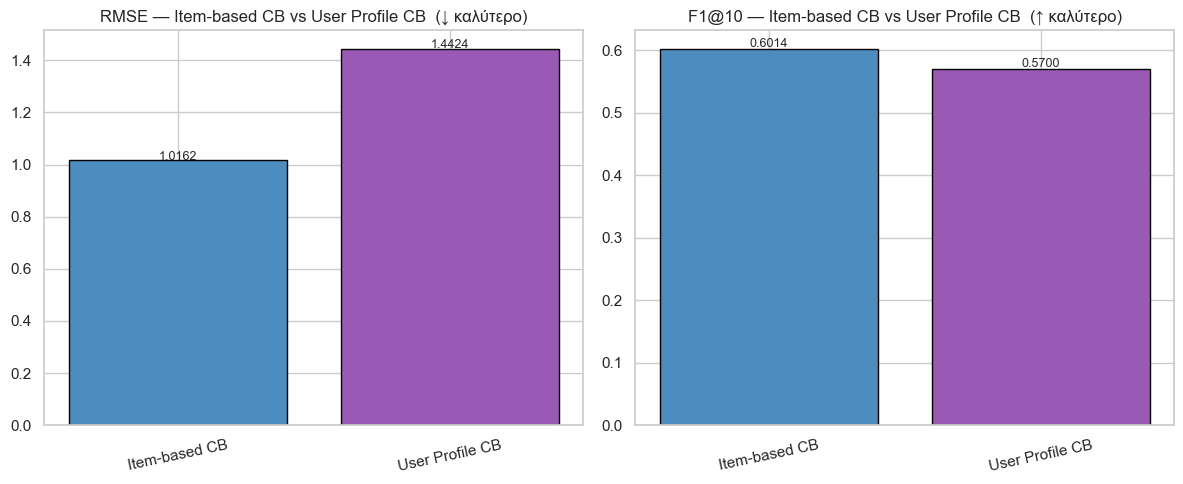

In [8]:
# ── User Profile CB ────────────────────────────────────────────────────────────
# user_profile(u) = Σ r(u,j) × feat(j) / Σ r(u,j)  (weighted mean of genre vectors)
# pred(u, i) = cosine_sim(profile_u, feat_i) → κλιμάκωση [0,1] → [1,5]

print('Building user profiles...')
user_profiles = {}
for uid, rated in user_ratings_dict.items():
    rated_ids = [iid for iid in rated if iid in genre_df.index]
    if not rated_ids:
        continue
    ratings_arr = np.array([rated[iid] for iid in rated_ids], dtype=float)
    vecs        = genre_df.loc[rated_ids].values.astype(float)
    user_profiles[uid] = np.dot(ratings_arr, vecs) / ratings_arr.sum()
print(f'Profiles για {len(user_profiles)} users.')

def up_predict(user_id, item_id):
    if user_id not in user_profiles or item_id not in genre_df.index:
        return GLOBAL_MEAN
    profile  = user_profiles[user_id]
    item_vec = genre_df.loc[item_id].values.astype(float)
    p_norm   = np.linalg.norm(profile)
    i_norm   = np.linalg.norm(item_vec)
    if p_norm == 0 or i_norm == 0:
        return GLOBAL_MEAN
    sim = np.dot(profile, item_vec) / (p_norm * i_norm)  # cosine ∈ [0,1]
    return float(np.clip(1 + sim * 4, 1, 5))             # [0,1] → [1,5]

print('Υπολογισμός User Profile predictions στο test set...')
test['up_pred'] = test.apply(
    lambda row: up_predict(row['user_id'], row['item_id']), axis=1
)

rmse_up = np.sqrt(((test['rating'] - test['up_pred'])**2).mean())
mae_up  = (test['rating'] - test['up_pred']).abs().mean()
print(f'\nUser Profile CB  RMSE: {rmse_up:.4f}  MAE: {mae_up:.4f}')

results_up = {}
for k in [5, 10]:
    p, r, f1 = precision_recall_f1_at_k(test, 'up_pred', k=k)
    results_up[k] = {'Precision': p, 'Recall': r, 'F1': f1}
    print(f'K={k:2d}  Precision={p:.4f}  Recall={r:.4f}  F1={f1:.4f}')

# ── Σύγκριση Item-based CB vs User Profile CB ──────────────────────────────────
cb_comp = pd.DataFrame([
    {'Μοντέλο': 'Item-based CB',
     'RMSE': rmse_cb, 'MAE': mae_cb,
     'Precision@5':  results_cb[5]['Precision'],  'Recall@5':  results_cb[5]['Recall'],  'F1@5':  results_cb[5]['F1'],
     'Precision@10': results_cb[10]['Precision'], 'Recall@10': results_cb[10]['Recall'], 'F1@10': results_cb[10]['F1']},
    {'Μοντέλο': 'User Profile CB',
     'RMSE': rmse_up, 'MAE': mae_up,
     'Precision@5':  results_up[5]['Precision'],  'Recall@5':  results_up[5]['Recall'],  'F1@5':  results_up[5]['F1'],
     'Precision@10': results_up[10]['Precision'], 'Recall@10': results_up[10]['Recall'], 'F1@10': results_up[10]['F1']},
])

print('\n=== Σύγκριση CB Προσεγγίσεων ===')
print(cb_comp.set_index('Μοντέλο').round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#4C8CBF', '#9B59B6']

axes[0].bar(cb_comp['Μοντέλο'], cb_comp['RMSE'], color=colors, edgecolor='black')
axes[0].set_title('RMSE — Item-based CB vs User Profile CB  (↓ καλύτερο)')
axes[0].tick_params(axis='x', rotation=12)
for i, v in enumerate(cb_comp['RMSE']):
    axes[0].text(i, v + 0.003, f'{v:.4f}', ha='center', fontsize=9)

axes[1].bar(cb_comp['Μοντέλο'], cb_comp['F1@10'], color=colors, edgecolor='black')
axes[1].set_title('F1@10 — Item-based CB vs User Profile CB  (↑ καλύτερο)')
axes[1].tick_params(axis='x', rotation=12)
for i, v in enumerate(cb_comp['F1@10']):
    axes[1].text(i, v + 0.003, f'{v:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/03b_cb_methods_comparison.png', dpi=150)
plt.show()

## 7. Top-10 Συστάσεις για Παράδειγμα Χρήστη

In [9]:
def get_cb_recommendations(user_id, n=10):
    seen    = set(train[train['user_id'] == user_id]['item_id'].tolist())
    unseen  = [iid for iid in movies['item_id'] if iid not in seen]
    preds   = sorted([(iid, cb_predict(user_id, iid)) for iid in unseen],
                     key=lambda x: x[1], reverse=True)
    top_ids = [iid for iid, _ in preds[:n]]
    return movies[movies['item_id'].isin(top_ids)][['item_id','title','genres']]

sample_user = 1
recs = get_cb_recommendations(sample_user)
print(f'Top-10 CB συστάσεις για User {sample_user}:')
print(recs.to_string(index=False))

Top-10 CB συστάσεις για User 1:
 item_id                                                title genres
     632          Land and Freedom (Tierra y libertad) (1995)    War
     665                                   Underground (1995)    War
     760                                    Stalingrad (1993)    War
     777                                Pharaoh's Army (1995)    War
    1450 Prisoner of the Mountains (Kavkazsky Plennik) (1996)    War
    1927                All Quiet on the Western Front (1930)    War
    2669                                Pork Chop Hill (1959)    War
    2670                          Run Silent, Run Deep (1958)    War
    3066                             Tora! Tora! Tora! (1970)    War
    3339                                 Cross of Iron (1977)    War


## 8. Αποθήκευση

In [10]:
cb_results = {'rmse': rmse_cb, 'mae': mae_cb, 'precision_recall_f1': results_cb}
with open('../results/cb_results.json', 'w') as f:
    json.dump(cb_results, f, indent=2)

test[['user_id','item_id','rating','cb_pred']].to_csv('../data/test_cb_preds.csv', index=False)

print('Αποθηκεύτηκε.')
print(f'\nContent-Based Summary:')
print(f'  RMSE: {rmse_cb:.4f}  |  MAE: {mae_cb:.4f}')
print(f'  Precision@10: {results_cb[10]["Precision"]:.4f}')
print(f'  Recall@10:    {results_cb[10]["Recall"]:.4f}')
print(f'  F1@10:        {results_cb[10]["F1"]:.4f}')

Αποθηκεύτηκε.

Content-Based Summary:
  RMSE: 1.0162  |  MAE: 0.8119
  Precision@10: 0.6072
  Recall@10:    0.5956
  F1@10:        0.6014
